<a href="https://colab.research.google.com/github/BunnyBrewster1724/CyberSec_Insider_Threat_Detection/blob/main/CS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import hstack

In [15]:
print("--- 1. Preparing an Enhanced Log Message Dataset ---")
# This dataset is larger and slightly imbalanced (more benign logs than threats),
# which is more representative of a real-world system.
data = {
    'log_message': [
        # Benign Errors (label 0) - Total 30
        'ERROR: NullPointerException at line 54 in user_profile.py',
        'WARN: Connection to database timed out after 3000ms',
        'ERROR: File not found at path /var/www/images/profile.jpg',
        'TypeError: cannot concatenate str and int objects',
        'INFO: User session for user_id 123 has expired',
        'WARN: API response time exceeded 2000ms for endpoint /api/data',
        'ERROR: Could not connect to Redis server at 127.0.0.1:6379',
        'IndexError: list index out of range',
        'KeyError: "config_key" not found in settings',
        'WARN: Disk space is running low on /dev/sda1',
        'INFO: Application startup sequence initiated.',
        'DEBUG: Caching layer returned a hit for key: user:123:profile',
        'ERROR: SMTP server connection refused on port 587',
        'ValueError: invalid literal for int() with base 10: "abc"',
        'WARN: SSL certificate for domain example.com expires in 10 days',
        'INFO: Database migration script 20230105_add_users_table.sql completed successfully.',
        'ERROR: Memory allocation failed for object of size 512MB',
        'WARN: Deprecated function `old_function()` called. Please use `new_function()` instead.',
        'INFO: Request to /api/healthcheck returned status 200 OK',
        'ERROR: UnicodeDecodeError: "utf-8" codec can\'t decode byte 0xff in position 0',
        'WARN: High CPU usage detected: 95% for 5 minutes',
        'DEBUG: SQL Query executed in 150ms: SELECT * FROM users WHERE id=?',
        'ERROR: Cannot open file for writing: /var/log/app.log',
        'INFO: Batch job "daily_report_generator" started.',
        'WARN: Third-party API rate limit reached. Retrying in 60 seconds.',
        'AttributeError: "NoneType" object has no attribute "name"',
        'ERROR: Failed to parse JSON response from /api/config',
        'INFO: User user@example.com successfully logged out.',
        'DEBUG: Variable `x` has value: 42',
        'ERROR: Socket timeout while connecting to payment gateway',


        # Potential Threats (label 1) - Total 20
        'ERROR: Authentication failed for user admin from IP 192.168.1.101',
        'FATAL: Access denied for user "guest" on database "production_db"',
        'WARN: Possible SQL injection attempt detected from 10.0.0.55: "OR 1=1"',
        'ERROR: Permission denied to access /etc/shadow',
        'FATAL: Multiple failed login attempts for user root from 203.0.113.10',
        'WARN: Cross-Site Scripting (XSS) pattern detected in input field "comment"',
        'ERROR: Invalid characters received in API token from 198.51.100.22',
        'FATAL: Command execution attempt detected: "cat /etc/passwd"',
        'ERROR: User enumeration attempt detected for usernames: admin, root, administrator',
        'WARN: Directory traversal attempt detected: "../../../../etc/hosts"',
        'ERROR: Suspicious user agent "sqlmap" detected from 210.15.2.3',
        'FATAL: Unauthorized API key usage detected for endpoint /api/v1/admin',
        'WARN: Malformed request received, potential buffer overflow attempt from 172.16.0.4',
        'ERROR: Brute-force attempt on SSH for user `deploy` from IP 45.33.32.156',
        'FATAL: Shellshock vulnerability exploit attempt detected in HTTP headers',
        'WARN: Log4Shell JNDI lookup pattern detected in user input',
        'ERROR: Unexpected file modification in /var/www/html/index.php',
        'FATAL: Rootkit-like activity detected, kernel module loaded.',
        'WARN: Data exfiltration pattern detected: large outbound transfer to unknown IP',
        'ERROR: Credential stuffing attack detected against /login endpoint',
    ],
    'label': [0]*30 + [1]*20  # 30 benign, 20 threats
}
df = pd.DataFrame(data)
print(f"Dataset enhanced. New size: {len(df)} log samples.\n")

--- 1. Preparing an Enhanced Log Message Dataset ---
Dataset enhanced. New size: 50 log samples.



In [16]:
print("--- 2. Engineering Features from Log Messages ---")

# Function to extract handcrafted features from a log message
def extract_log_features(log):
    features = {}
    # Count keywords that strongly indicate a threat
    threat_keywords = ['failed', 'denied', 'injection', 'fatal', 'xss', 'traversal', 'enumeration', 'execution']
    features['threat_keyword_count'] = sum([log.lower().count(keyword) for keyword in threat_keywords])
    # Check if an IP address is mentioned, often present in access logs
    features['contains_ip_address'] = 1 if re.search(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', log) else 0
    # Higher number of special characters can indicate injection attempts
    features['special_chars_count'] = len(re.findall(r'[!\"#$%&\'()*+,-./:;<=>?@\[\\\]^_`{|}~]', log))
    return features

# Apply the function to create our handcrafted features
handcrafted_features = df['log_message'].apply(lambda log: pd.Series(extract_log_features(log)))

# Use TF-IDF on the words in the log message
# This captures the overall vocabulary and phrasing
tfidf_vectorizer = TfidfVectorizer(analyzer='word', stop_words='english', max_features=100)
tfidf_features = tfidf_vectorizer.fit_transform(df['log_message'])

# Combine the handcrafted features with the TF-IDF features
X = hstack([tfidf_features, handcrafted_features.astype(float)])
y = df['label']

print(f"Combined feature matrix created with shape: {X.shape}\n")


--- 2. Engineering Features from Log Messages ---
Combined feature matrix created with shape: (50, 103)



In [17]:
print("--- 3. Training and Evaluating the Threat Detection Model ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("Model training complete.")
y_pred = model.predict(X_test)
print("\n--- Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.2f}\n")


--- 3. Training and Evaluating the Threat Detection Model ---
Model training complete.

--- Performance Metrics ---
Accuracy:  0.93
Precision: 1.00
Recall:    0.83
F1-Score:  0.91



--- 4. Visualizing Results with a Confusion Matrix ---


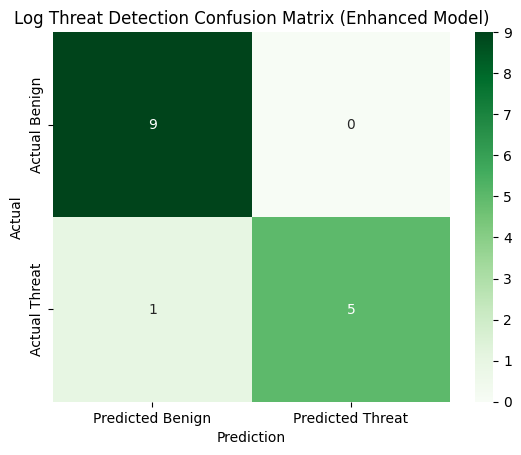

In [19]:
print("--- 4. Visualizing Results with a Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Benign', 'Predicted Threat'],
            yticklabels=['Actual Benign', 'Actual Threat'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Log Threat Detection Confusion Matrix (Enhanced Model)')
plt.show()


In [21]:
print("\n--- 5. Predicting on New, Unseen Log Messages ---")
new_logs = [
    'WARN: SSL certificate is about to expire.',                             # Clearly Benign
    'AttributeError: "NoneType" object has no attribute "split"',            # Clearly Benign
    'FATAL: Unauthorized command execution attempt: "rm -rf /" from user "www-data"', # Clearly Threat
    'WARN: Suspicious login from IP 203.0.113.55 for user that does not exist' # Clearly Threat
]

new_handcrafted_features = pd.DataFrame([extract_log_features(log) for log in new_logs])
new_tfidf_features = tfidf_vectorizer.transform(new_logs)
new_X = hstack([new_tfidf_features, new_handcrafted_features.astype(float)])
new_predictions = model.predict(new_X)

for log, prediction in zip(new_logs, new_predictions):
    result = "Potential Threat" if prediction == 1 else "Benign Error"
    print(f"Log: '{log}'")
    print(f"--> Prediction: {result}\n")


--- 5. Predicting on New, Unseen Log Messages ---
Log: 'WARN: SSL certificate is about to expire.'
--> Prediction: Benign Error

Log: 'AttributeError: "NoneType" object has no attribute "split"'
--> Prediction: Benign Error

Log: 'FATAL: Unauthorized command execution attempt: "rm -rf /" from user "www-data"'
--> Prediction: Potential Threat

Log: 'WARN: Suspicious login from IP 203.0.113.55 for user that does not exist'
--> Prediction: Potential Threat

